Dataset Loaded Successfully!

First 5 Rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Dataset Shape:
(1000, 8)

Column Names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test

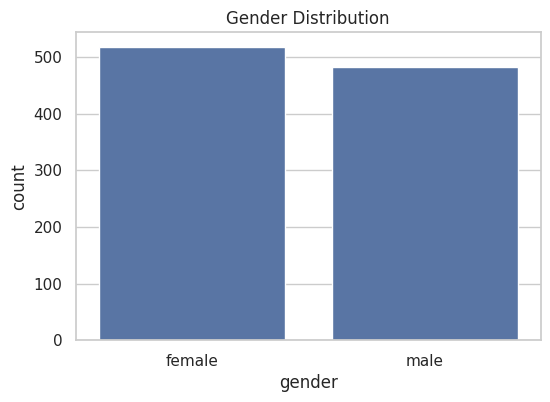

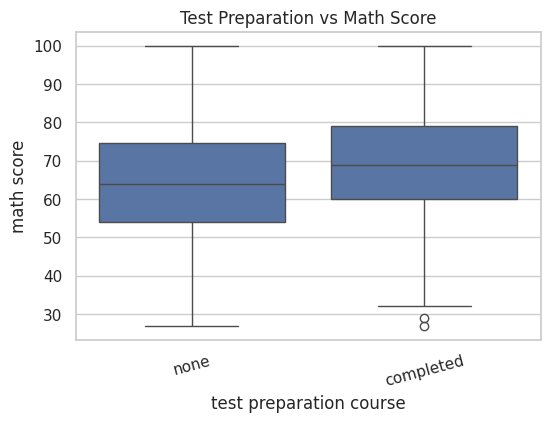

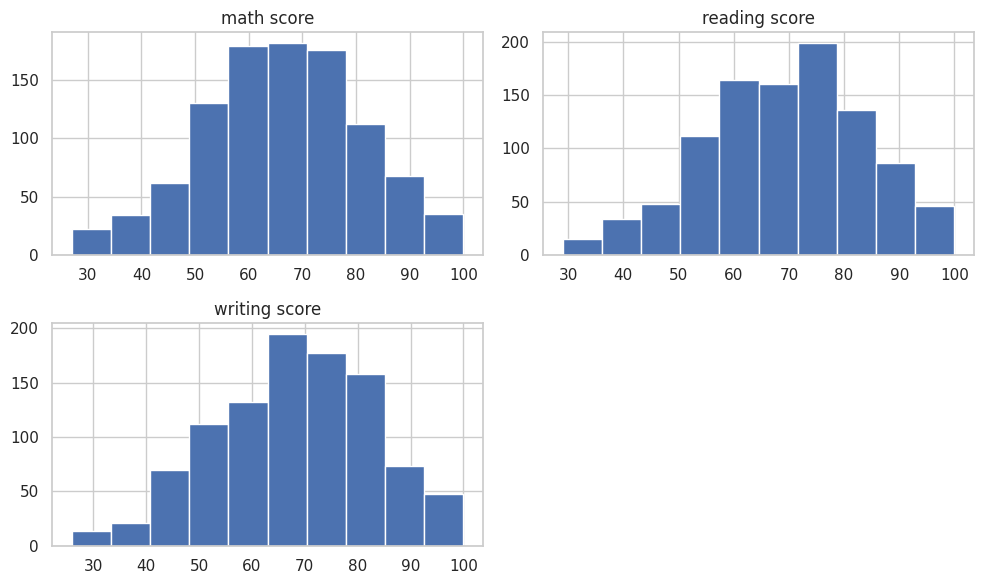

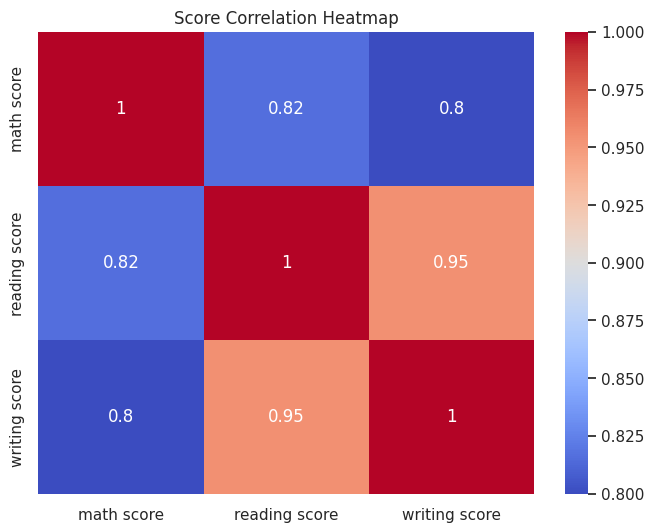


Cleaned dataset saved as 'cleaned_student_performance.csv'

Project Completed Successfully!


In [9]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 2. Load Dataset
df = pd.read_csv('/content/archive (4).zip')
df.columns = df.columns.str.strip()
print("Dataset Loaded Successfully!\n")
# 3. Basic Exploration
print("First 5 Rows:")
print(df.head())
print("\nDataset Shape:")
print(df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
# 4. Handle Missing Values
print("\nMissing Values:")
print(df.isnull().sum())
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print("\nMissing values after handling:")
print(df.isnull().sum())
# 5. Remove Duplicate Rows
print("\nDuplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)
# 6. Handle Outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])
print("\nOutliers handled successfully.")
# 7. Data Visualization
sns.set(style="whitegrid")
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()
# ---- Test Preparation vs Math Score ----
plt.figure(figsize=(6,4))
sns.boxplot(x='test preparation course', y='math score', data=df)
plt.title("Test Preparation vs Math Score")
plt.xticks(rotation=15)
plt.show()
# ---- Average Scores Histogram ----
df[numeric_cols].hist(figsize=(10,6))
plt.tight_layout()
plt.show()
# ---- Correlation Heatmap ----
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Score Correlation Heatmap")
plt.show()
# 8. Save Cleaned Dataset
df.to_csv("cleaned_student_performance.csv", index=False)
print("\nCleaned dataset saved as 'cleaned_student_performance.csv'")
print("\nProject Completed Successfully!")